Episode 0, Reward: 590.90
Episode 50, Reward: 2019.55
Episode 100, Reward: 3012.81
Episode 150, Reward: 3108.54
Episode 200, Reward: 2881.32
Episode 250, Reward: 2604.66
Episode 300, Reward: 2623.25
Episode 350, Reward: 2822.43
Episode 400, Reward: 3335.01
Episode 450, Reward: 2568.44

Policy Evaluation Reward: 2350.4170044086786

--- Validation ---
State: [0.78118061 0.00294948 0.32783767 0.77061219 0.22938781 0.4534413
 0.0266493  0.02133315 0.125     ]
Q-values: [1078.83344864 1071.87541407 1052.86186076]
Best Action: Do Nothing


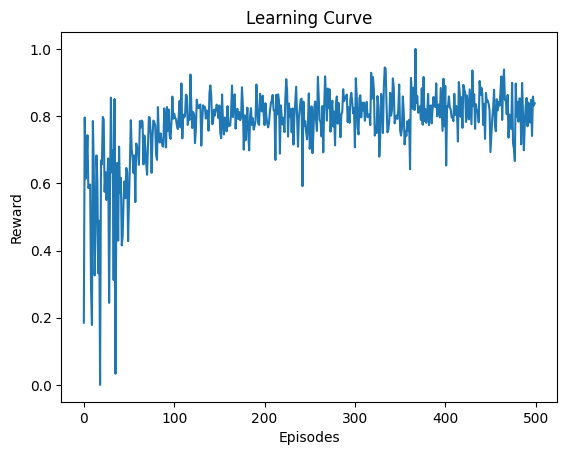

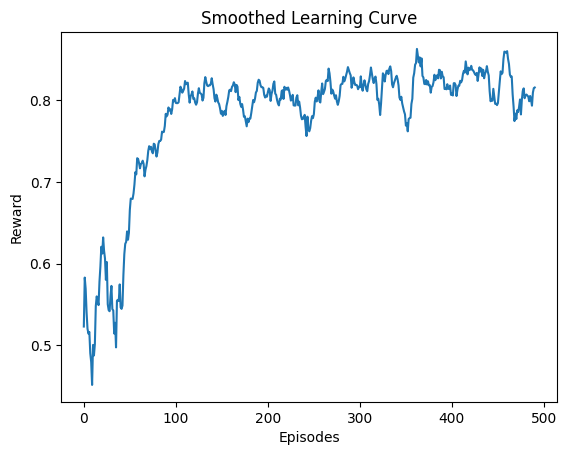

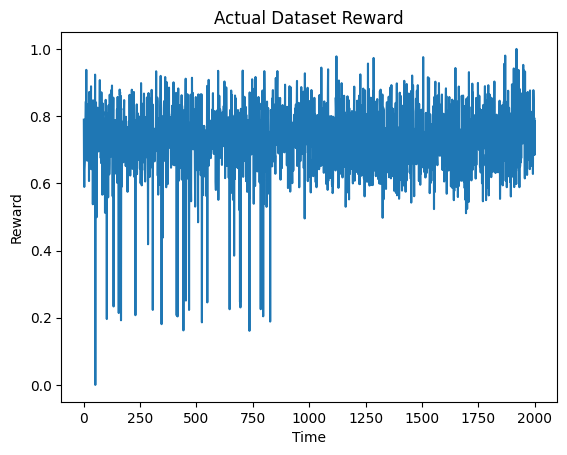

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# -------------------------------------------------------
# 1. Load Data
# -------------------------------------------------------
df = pd.read_csv("Transformer_Data_Merged.csv")
df = df.fillna(0)

df["Scheduled_Hours"] = df["Scheduled_Hours"].replace(0, 1)
df["MTBF_Hours"] = df["MTBF_Hours"].replace(0, 1)
df["MTTR_Hours"] = df["MTTR_Hours"].replace(0, 1)

# -------------------------------------------------------
# 2. Feature Engineering
# -------------------------------------------------------
df["Failure_Rate"] = 1.0 / df["MTBF_Hours"]
df["Repair_Efficiency"] = 1.0 / df["MTTR_Hours"]
df["Utilization_Stress"] = df["Utilization_Rate"] * df["Scheduled_Hours"]
df["Downtime_Ratio"] = df["Downtime_Duration"] / df["Scheduled_Hours"]

df["Maintenance_Cost_Rate"] = df["Maintenance_Parts_Cost"] / (df["Scheduled_Hours"] + 1)
df["Energy_Cost_Rate"] = df["Energy_Consumption_kWh"] / (df["Output_Quantity"] + 1)
df["Reject_Rate"] = df["Reject_Quantity"] / (df["Output_Quantity"] + 1)

df["Health_Index"] = (
    0.35 * df["Uptime_Percentage"] +
    0.25 * (1 - df["Failure_Rate"]) +
    0.20 * (1 - df["Downtime_Ratio"]) +
    0.20 * (1 - df["Reject_Rate"])
)

state_features = [
    "Health_Index", "Failure_Rate", "Repair_Efficiency",
    "Utilization_Stress", "Downtime_Ratio",
    "Maintenance_Cost_Rate", "Energy_Cost_Rate",
    "Reject_Rate", "Number_of_Breakdowns"
]

states = df[state_features].values

# -------------------------------------------------------
# 3. Reward from dataset (for plotting baseline)
# -------------------------------------------------------
df["Reward"] = (
    df["Net_Profit"]
    - df["DownTime_Cost"]
    - df["Maintenance_Parts_Cost"]
    - df["Energy_Consumption_kWh"]
)

dataset_rewards = df["Reward"].values

# -------------------------------------------------------
# 4. Normalize
# -------------------------------------------------------
scaler = MinMaxScaler()
states = scaler.fit_transform(states)

# -------------------------------------------------------
# 5. Train-Test Split
# -------------------------------------------------------
X_train, X_test = train_test_split(states, test_size=0.2, random_state=42)

# -------------------------------------------------------
# 6. Q-learning setup
# -------------------------------------------------------
num_actions = 3
state_dim = X_train.shape[1]

weights = np.zeros((num_actions, state_dim))

alpha = 0.01
gamma = 0.95
epsilon = 0.2
episodes = 500

def get_q_values(state):
    return np.dot(weights, state)

def choose_action(state):
    if np.random.rand() < epsilon:
        return np.random.randint(num_actions)
    return np.argmax(get_q_values(state))

# -------------------------------------------------------
# 7. Probabilistic Transition Model
# -------------------------------------------------------
def apply_probabilistic_change(value, prob_inc, prob_dec, step=0.05):
    r = np.random.rand()
    if r < prob_inc:
        value += step
    elif r < prob_inc + prob_dec:
        value -= step
    return value

def environment_step(state, action):
    next_state = state.copy()

    HEALTH, FAILURE, DOWNTIME = 0, 1, 4

    if action == 0:  # Do nothing
        next_state[HEALTH] = apply_probabilistic_change(next_state[HEALTH], 0.1, 0.6)
        next_state[FAILURE] = apply_probabilistic_change(next_state[FAILURE], 0.7, 0.1)
        next_state[DOWNTIME] = apply_probabilistic_change(next_state[DOWNTIME], 0.6, 0.1)

    elif action == 1:  # Preventive
        next_state[HEALTH] = apply_probabilistic_change(next_state[HEALTH], 0.7, 0.1)
        next_state[FAILURE] = apply_probabilistic_change(next_state[FAILURE], 0.1, 0.7)
        next_state[DOWNTIME] = apply_probabilistic_change(next_state[DOWNTIME], 0.1, 0.6)

    elif action == 2:  # Corrective
        if np.random.rand() < 0.9:
            next_state[HEALTH] = 0.9
            next_state[FAILURE] = 0.1
            next_state[DOWNTIME] = 0.1
        else:
            next_state[HEALTH] = 0.6
            next_state[FAILURE] = 0.3
            next_state[DOWNTIME] = 0.3

    # small noise
    next_state += np.random.normal(0, 0.01, size=len(state))
    next_state = np.clip(next_state, 0, 1)

    return next_state

# -------------------------------------------------------
# 8. Reward Function (Action-dependent)
# -------------------------------------------------------
def compute_reward(state, action):
    health = state[0]
    downtime = state[4]

    reward = 100 * health - 80 * downtime

    if action == 1:
        reward -= 20
    elif action == 2:
        reward -= 50

    return reward

# -------------------------------------------------------
# 9. Training Loop
# -------------------------------------------------------
episode_rewards = []

for ep in range(episodes):
    state = X_train[np.random.randint(len(X_train))]
    total_reward = 0

    for step in range(50):
        action = choose_action(state)

        next_state = environment_step(state, action)
        reward = compute_reward(state, action)

        q_current = np.dot(weights[action], state)
        q_next = np.max(get_q_values(next_state))

        td_target = reward + gamma * q_next
        td_error = td_target - q_current

        weights[action] += alpha * td_error * state

        state = next_state
        total_reward += reward

    episode_rewards.append(total_reward)

    if ep % 50 == 0:
        print(f"Episode {ep}, Reward: {total_reward:.2f}")

# -------------------------------------------------------
# 10. Evaluation
# -------------------------------------------------------
def evaluate_policy():
    state = X_test[0]
    total_reward = 0

    for _ in range(50):
        action = np.argmax(get_q_values(state))
        state = environment_step(state, action)
        reward = compute_reward(state, action)
        total_reward += reward

    return total_reward

print("\nPolicy Evaluation Reward:", evaluate_policy())

# -------------------------------------------------------
# 11. Validation (Sample Input)
# -------------------------------------------------------
sample_state = X_test[0]
q_vals = get_q_values(sample_state)

action_map = {
    0: "Do Nothing",
    1: "Preventive Maintenance",
    2: "Corrective Maintenance"
}

print("\n--- Validation ---")
print("State:", sample_state)
print("Q-values:", q_vals)
print("Best Action:", action_map[np.argmax(q_vals)])

# -------------------------------------------------------
# 12. Plotting
# -------------------------------------------------------
def moving_average(data, window=10):
    return np.convolve(data, np.ones(window)/window, mode='valid')

def plot_learning_curves(ep_rewards, actual_rewards):
    def normalize(x):
        return (x - np.min(x)) / (np.max(x) - np.min(x))
    rl_norm = normalize(ep_rewards)
    base_norm = normalize(actual_rewards)
    plt.figure()
    plt.plot(rl_norm)
    plt.title("Learning Curve")
    plt.xlabel("Episodes")
    plt.ylabel("Reward")
    plt.show()

    plt.figure()
    plt.plot(moving_average(rl_norm))
    plt.title("Smoothed Learning Curve")
    plt.xlabel("Episodes")
    plt.ylabel("Reward")
    plt.show()

    plt.figure()
    plt.plot(base_norm)
    plt.title("Actual Dataset Reward")
    plt.xlabel("Time")
    plt.ylabel("Reward")
    plt.show()

plot_learning_curves(episode_rewards, dataset_rewards)